In [1]:
# Project 9 - Autocomplete & Autocorrect
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 2 - Create Word Dataset
text = """
the quick brown fox jumps over the lazy dog
hello world this is a sample text for autocomplete
python programming is fun and interesting
data science machine learning artificial intelligence
natural language processing text analytics
the cat sat on the mat the dog ran fast
apple banana orange mango grapes strawberry
programming coding software development technology
beautiful wonderful amazing fantastic excellent
school college university education learning study
"""

# Process words
words = re.findall(r'\b[a-z]+\b', text.lower())
word_freq = Counter(words)

print("Total words:", len(words))
print("Unique words:", len(word_freq))
print("\nMost common words:")
print(word_freq.most_common(10))

Total words: 67
Unique words: 58

Most common words:
[('the', 5), ('dog', 2), ('is', 2), ('text', 2), ('programming', 2), ('learning', 2), ('quick', 1), ('brown', 1), ('fox', 1), ('jumps', 1)]


In [3]:
# Step 3 - Autocomplete Function
def autocomplete(prefix, word_list, n=5):
    prefix = prefix.lower()
    suggestions = [word for word in word_list 
                   if word.startswith(prefix)]
    suggestions = sorted(suggestions, 
                        key=lambda x: word_freq[x], 
                        reverse=True)
    return suggestions[:n]

# Test Autocomplete
print("=== AUTOCOMPLETE DEMO ===")
tests = ['pr', 'le', 'te', 'sc', 'an']
for prefix in tests:
    suggestions = autocomplete(prefix, word_freq.keys())
    print(f"Type '{prefix}' → Suggestions: {suggestions}")

=== AUTOCOMPLETE DEMO ===
Type 'pr' → Suggestions: ['programming', 'processing']
Type 'le' → Suggestions: ['learning']
Type 'te' → Suggestions: ['text', 'technology']
Type 'sc' → Suggestions: ['science', 'school']
Type 'an' → Suggestions: ['and', 'analytics']


In [4]:
# Step 4 - Autocorrect Function
def edit_distance(word1, word2):
    m, n = len(word1), len(word2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if word1[i-1] == word2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j],
                                   dp[i][j-1],
                                   dp[i-1][j-1])
    return dp[m][n]

def autocorrect(word, word_list, n=3):
    word = word.lower()
    if word in word_list:
        return [word]
    distances = [(w, edit_distance(word, w)) 
                 for w in word_list]
    distances = sorted(distances, key=lambda x: x[1])
    return [w for w, d in distances[:n]]

# Test Autocorrect
print("=== AUTOCORRECT DEMO ===")
misspelled = ['progaming', 'learing', 'scince', 
              'teh', 'artifical']
for word in misspelled:
    corrections = autocorrect(word, word_freq.keys())
    print(f"'{word}' → Corrected to: {corrections}")

=== AUTOCORRECT DEMO ===
'progaming' → Corrected to: ['programming', 'processing', 'coding']
'learing' → Corrected to: ['learning', 'amazing', 'coding']
'scince' → Corrected to: ['science', 'quick', 'sample']
'teh' → Corrected to: ['the', 'text', 'fox']
'artifical' → Corrected to: ['artificial', 'natural', 'beautiful']


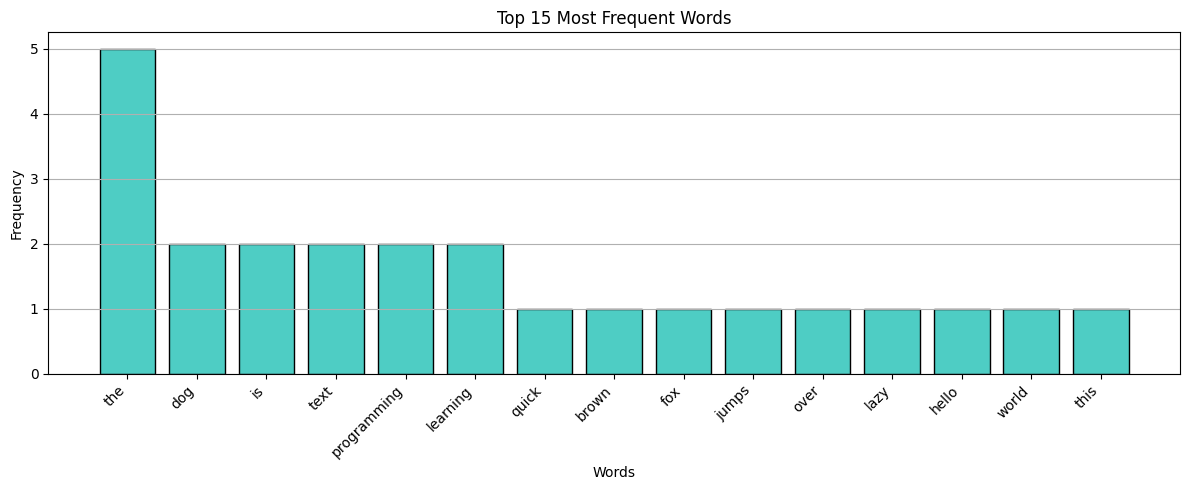

In [5]:
# Step 5 - Visualize Word Frequency
top_words = word_freq.most_common(15)
words_list = [w[0] for w in top_words]
freq_list = [w[1] for w in top_words]

plt.figure(figsize=(12, 5))
plt.bar(words_list, freq_list, color='#4ECDC4', edgecolor='black')
plt.title('Top 15 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [6]:
# Step 6 - Final Summary
print("=" * 55)
print("   AUTOCOMPLETE & AUTOCORRECT - SUMMARY")
print("=" * 55)

print(f"\n Total Words Processed: {len(words)}")
print(f" Unique Words in Dictionary: {len(word_freq)}")

print("\n=== AUTOCOMPLETE RESULTS ===")
tests = ['pr', 'le', 'te', 'sc', 'an']
for prefix in tests:
    suggestions = autocomplete(prefix, word_freq.keys())
    print(f" '{prefix}' → {suggestions}")

print("\n=== AUTOCORRECT RESULTS ===")
misspelled = ['progaming', 'learing', 'scince', 'teh']
for word in misspelled:
    corrections = autocorrect(word, word_freq.keys())
    print(f" '{word}' → {corrections[0]}")

print("\n=== KEY FINDINGS ===")
print(" 1. Autocomplete suggests words by prefix")
print(" 2. Autocorrect fixes spelling using edit distance")
print(" 3. More data = better suggestions")
print(" 4. Algorithm works in real-time")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Add larger word dictionary for better results")
print(" 2. Use frequency data for smarter suggestions")
print(" 3. Implement in mobile keyboard apps")
print(" 4. Add context-aware predictions")
print("=" * 55)
print(" Autocomplete & Autocorrect Completed!")
print("=" * 55)

   AUTOCOMPLETE & AUTOCORRECT - SUMMARY

 Total Words Processed: 67
 Unique Words in Dictionary: 58

=== AUTOCOMPLETE RESULTS ===
 'pr' → ['programming', 'processing']
 'le' → ['learning']
 'te' → ['text', 'technology']
 'sc' → ['science', 'school']
 'an' → ['and', 'analytics']

=== AUTOCORRECT RESULTS ===
 'progaming' → programming
 'learing' → learning
 'scince' → science
 'teh' → the

=== KEY FINDINGS ===
 1. Autocomplete suggests words by prefix
 2. Autocorrect fixes spelling using edit distance
 3. More data = better suggestions
 4. Algorithm works in real-time

=== RECOMMENDATIONS ===
 1. Add larger word dictionary for better results
 2. Use frequency data for smarter suggestions
 3. Implement in mobile keyboard apps
 4. Add context-aware predictions
 Autocomplete & Autocorrect Completed!
